In [16]:
# ===========================================
# EV Data Analysis Assignment
# Name: Anusha
# ===========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import folium

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

print("All libraries imported successfully!")

All libraries imported successfully!


In [17]:
# Load dataset
df = pd.read_csv("export.csv")

print("Dataset loaded successfully!")


Dataset loaded successfully!


In [18]:
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5UX43EU07S,Snohomish,Snohomish,WA,98296.0,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,44.0,279314360,POINT (-122.1389 47.87115),PUGET SOUND ENERGY INC,5.306105e+10
1,5YJ3E1EB5J,Yakima,Yakima,WA,98901.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,14.0,220635992,POINT (-120.50729 46.60464),PACIFICORP,5.307700e+10
2,WA1AAAGE5M,King,Seattle,WA,98112.0,2021,AUDI,E-TRON,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,222.0,43.0,282112967,POINT (-122.30207 47.64085),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5YJXCAE2XG,Kitsap,Bremerton,WA,98310.0,2016,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,200.0,23.0,103165100,POINT (-122.61136 47.5752),PUGET SOUND ENERGY INC,5.303508e+10
4,5YJ3E1EB5J,Yakima,Yakima,WA,98908.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,14.0,301024209,POINT (-120.60272 46.59656),PACIFICORP,5.307700e+10


In [19]:
df.shape

(289564, 16)

In [20]:
df.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Vehicle Location',
       'Electric Utility', '2020 Census Tract'],
      dtype='object')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289564 entries, 0 to 289563
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         289564 non-null  object 
 1   County                                             289555 non-null  object 
 2   City                                               289555 non-null  object 
 3   State                                              289564 non-null  object 
 4   Postal Code                                        289555 non-null  float64
 5   Model Year                                         289564 non-null  int64  
 6   Make                                               289564 non-null  object 
 7   Model                                              289564 non-null  object 
 8   Electric Vehicle Type                              289564 non-null  object

# Section 1: Data Cleaning

In [22]:
print("Rows and Columns:", df.shape)

Rows and Columns: (289564, 16)


In [23]:
df.isnull().sum()

VIN (1-10)                                             0
County                                                 9
City                                                   9
State                                                  0
Postal Code                                            9
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                        10
Legislative District                                 727
DOL Vehicle ID                                         0
Vehicle Location                                      16
Electric Utility                                       9
2020 Census Tract                                      9
dtype: int64

In [24]:
print("Rows and Columns:", df.shape)

Rows and Columns: (289564, 16)


In [25]:
missing = df.isnull().sum()

missing

VIN (1-10)                                             0
County                                                 9
City                                                   9
State                                                  0
Postal Code                                            9
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                        10
Legislative District                                 727
DOL Vehicle ID                                         0
Vehicle Location                                      16
Electric Utility                                       9
2020 Census Tract                                      9
dtype: int64

In [26]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 798


In [27]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent

VIN (1-10)                                           0.000000
County                                               0.003108
City                                                 0.003108
State                                                0.000000
Postal Code                                          0.003108
Model Year                                           0.000000
Make                                                 0.000000
Model                                                0.000000
Electric Vehicle Type                                0.000000
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0.000000
Electric Range                                       0.003453
Legislative District                                 0.251067
DOL Vehicle ID                                       0.000000
Vehicle Location                                     0.005526
Electric Utility                                     0.003108
2020 Census Tract                                    0.003108
dtype: f

In [28]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


In [29]:
df = df.drop_duplicates()

print(df.shape)

(289564, 16)


In [30]:
print("Base MSRP = 0 :", (df["Base MSRP"]==0).sum())

print("Electric Range = 0 :", (df["Electric Range"]==0).sum())

KeyError: 'Base MSRP'

In [31]:
import numpy as np

df["Base MSRP"] = df["Base MSRP"].replace(0,np.nan)

df["Electric Range"] = df["Electric Range"].replace(0,np.nan)

KeyError: 'Base MSRP'

In [32]:
list(df.columns)

['VIN (1-10)',
 'County',
 'City',
 'State',
 'Postal Code',
 'Model Year',
 'Make',
 'Model',
 'Electric Vehicle Type',
 'Clean Alternative Fuel Vehicle (CAFV) Eligibility',
 'Electric Range',
 'Legislative District',
 'DOL Vehicle ID',
 'Vehicle Location',
 'Electric Utility',
 '2020 Census Tract']

In [33]:
print("Dataset Shape:", df.shape)

Dataset Shape: (289564, 16)


In [34]:
df.isnull().sum()

VIN (1-10)                                             0
County                                                 9
City                                                   9
State                                                  0
Postal Code                                            9
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                        10
Legislative District                                 727
DOL Vehicle ID                                         0
Vehicle Location                                      16
Electric Utility                                       9
2020 Census Tract                                      9
dtype: int64

In [35]:
missing = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Percentage": (df.isnull().sum() / len(df) * 100).values
})

missing

,Column,Missing Values,Percentage
0,VIN (1-10),0,0.000000
1,County,9,0.003108
2,City,9,0.003108
3,State,0,0.000000
4,Postal Code,9,0.003108
5,Model Year,0,0.000000
6,Make,0,0.000000
7,Model,0,0.000000
8,Electric Vehicle Type,0,0.000000
9,Clean Alternative Fuel Vehicle (CAFV) Eligibility,0,0.000000


In [36]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


In [37]:
df["County"] = df["County"].fillna("Unknown")
df["City"] = df["City"].fillna("Unknown")
df["Electric Utility"] = df["Electric Utility"].fillna("Unknown")
df["Vehicle Location"] = df["Vehicle Location"].fillna("Unknown")

df["Postal Code"] = df["Postal Code"].fillna(df["Postal Code"].median())
df["Electric Range"] = df["Electric Range"].fillna(df["Electric Range"].median())
df["Legislative District"] = df["Legislative District"].fillna(df["Legislative District"].median())
df["2020 Census Tract"] = df["2020 Census Tract"].fillna(df["2020 Census Tract"].median())

In [38]:
df.isnull().sum()

VIN (1-10)                                           0
County                                               0
City                                                 0
State                                                0
Postal Code                                          0
Model Year                                           0
Make                                                 0
Model                                                0
Electric Vehicle Type                                0
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0
Electric Range                                       0
Legislative District                                 0
DOL Vehicle ID                                       0
Vehicle Location                                     0
Electric Utility                                     0
2020 Census Tract                                    0
dtype: int64

# Section 2: Exploratory Data Analysis (EDA)

In [39]:
df.describe()

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 Census Tract
count,289564.000000,289564.000000,289564.000000,289564.000000,2.895640e+05,2.895640e+05
mean,98179.341935,2022.255957,37.398478,28.808819,2.495999e+08,5.297009e+10
std,2595.425658,3.080426,76.740718,14.870437,6.267330e+07,1.656903e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.271862e+08,5.303301e+10
50%,98133.000000,2023.000000,0.000000,32.000000,2.670574e+08,5.303303e+10
75%,98388.000000,2024.000000,32.000000,42.000000,2.827402e+08,5.305394e+10
max,99801.000000,2027.000000,337.000000,49.000000,4.791150e+08,6.601095e+10


In [40]:
df["Electric Vehicle Type"].value_counts()

Electric Vehicle Type
Battery Electric Vehicle (BEV)            233544
Plug-in Hybrid Electric Vehicle (PHEV)     56020
Name: count, dtype: int64

In [41]:
df["Make"].value_counts().head(10)

Make
TESLA         118148
CHEVROLET      19808
NISSAN         16023
FORD           15930
KIA            14501
TOYOTA         13057
BMW            12024
HYUNDAI        11696
RIVIAN          9491
VOLKSWAGEN      7863
Name: count, dtype: int64

In [42]:
df["Model"].value_counts().head(10)

Model
MODEL Y           62979
MODEL 3           38325
LEAF              13406
MODEL S            7784
BOLT EV            7518
MODEL X            7106
IONIQ 5            7053
MUSTANG MACH-E     6764
ID.4               6312
R1S                5504
Name: count, dtype: int64

In [43]:
df["County"].value_counts().head(10)

County
King         140130
Snohomish     36508
Pierce        24162
Clark         18060
Thurston      10617
Kitsap        10023
Spokane        8329
Whatcom        7205
Benton         4304
Skagit         3440
Name: count, dtype: int64

In [44]:
df["City"].value_counts().head(10)

City
Seattle      44333
Bellevue     13909
Vancouver    10809
Redmond       9835
Bothell       9434
Kirkland      8207
Sammamish     7933
Renton        7696
Olympia       6790
Tacoma        6430
Name: count, dtype: int64

In [45]:
df["Model Year"].value_counts().sort_index()

Model Year
1999        2
2000        7
2002        1
2003        1
2008       17
2010       21
2011      532
2012     1301
2013     3831
2014     3107
2015     4343
2016     5025
2017     8341
2018    13926
2019    10677
2020    11927
2021    20608
2022    29937
2023    60332
2024    49277
2025    37044
2026    29058
2027      249
Name: count, dtype: int64

In [46]:
print("Average Electric Range:", df["Electric Range"].mean())

Average Electric Range: 37.3984784020113


In [47]:
print("Maximum Electric Range:", df["Electric Range"].max())

Maximum Electric Range: 337.0


In [48]:
print("Minimum Electric Range:", df["Electric Range"].min())

Minimum Electric Range: 0.0


In [49]:
df["Clean Alternative Fuel Vehicle (CAFV) Eligibility"].value_counts()

Clean Alternative Fuel Vehicle (CAFV) Eligibility
Eligibility unknown as battery range has not been researched    188456
Clean Alternative Fuel Vehicle Eligible                          77580
Not eligible due to low battery range                            23528
Name: count, dtype: int64

In [50]:
df["State"].value_counts()

State
WA    288838
CA       173
VA        91
FL        45
MD        42
TX        40
OR        27
CO        26
NV        24
NC        21
AZ        19
IL        19
GA        14
NY        14
MO        11
NJ         9
MI         9
MA         9
AL         9
DC         8
RI         7
ID         7
SC         7
NE         7
PA         6
CT         6
KY         6
TN         6
OH         5
WI         5
LA         5
NM         5
KS         4
NH         4
BC         3
AE         3
MN         3
IN         3
AR         2
SD         2
WY         2
HI         2
AK         2
UT         2
OK         2
IA         2
ME         2
MT         1
MS         1
QC         1
AP         1
GU         1
DE         1
Name: count, dtype: int64

# Section 3: Data Visualization

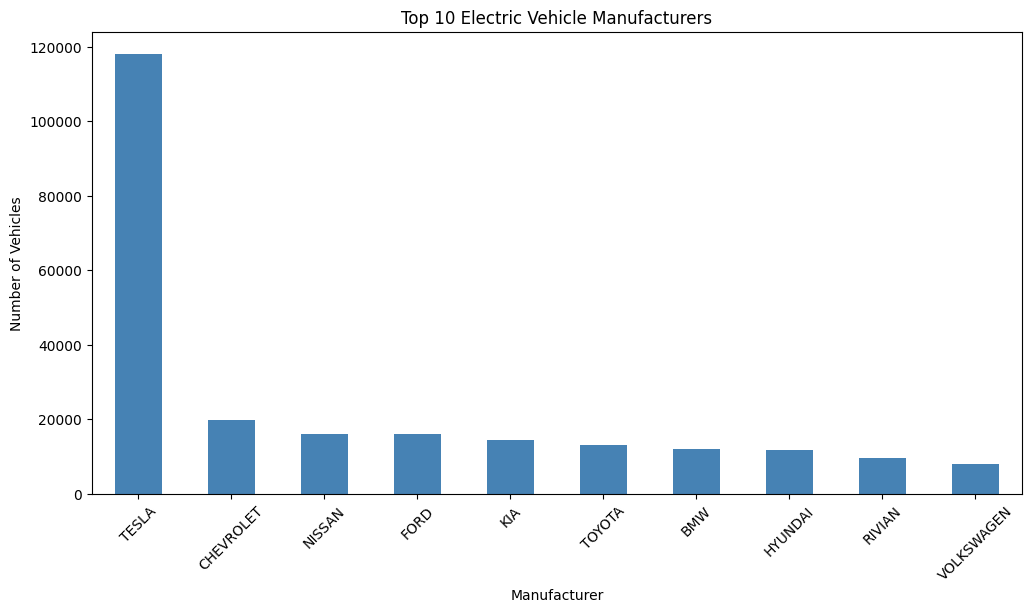

In [51]:
plt.figure(figsize=(12,6))

df["Make"].value_counts().head(10).plot(
    kind="bar",
    color="steelblue"
)

plt.title("Top 10 Electric Vehicle Manufacturers")
plt.xlabel("Manufacturer")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=45)

plt.show()

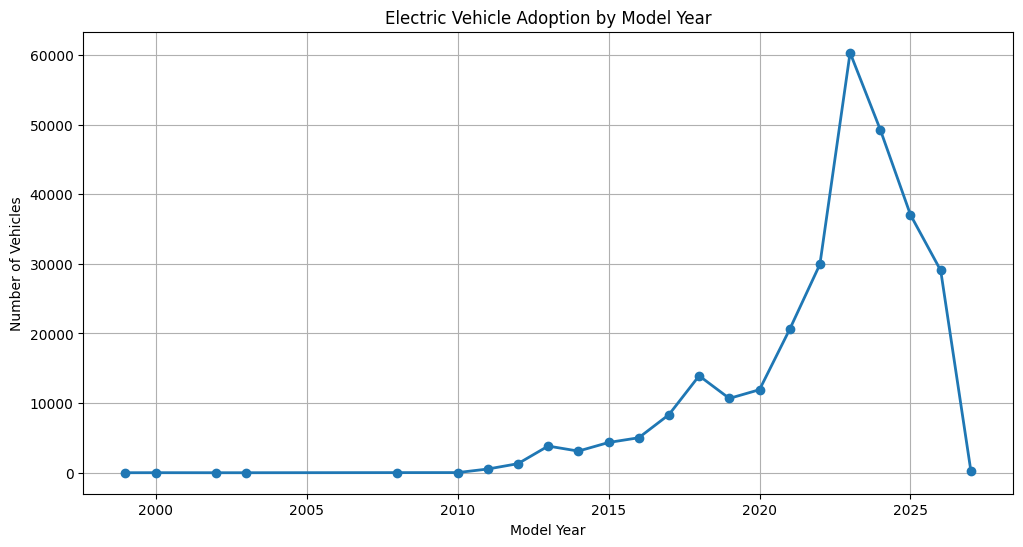

In [52]:
year_data = df["Model Year"].value_counts().sort_index()

plt.figure(figsize=(12,6))

plt.plot(
    year_data.index,
    year_data.values,
    marker="o",
    linewidth=2
)

plt.title("Electric Vehicle Adoption by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Number of Vehicles")

plt.grid(True)

plt.show()

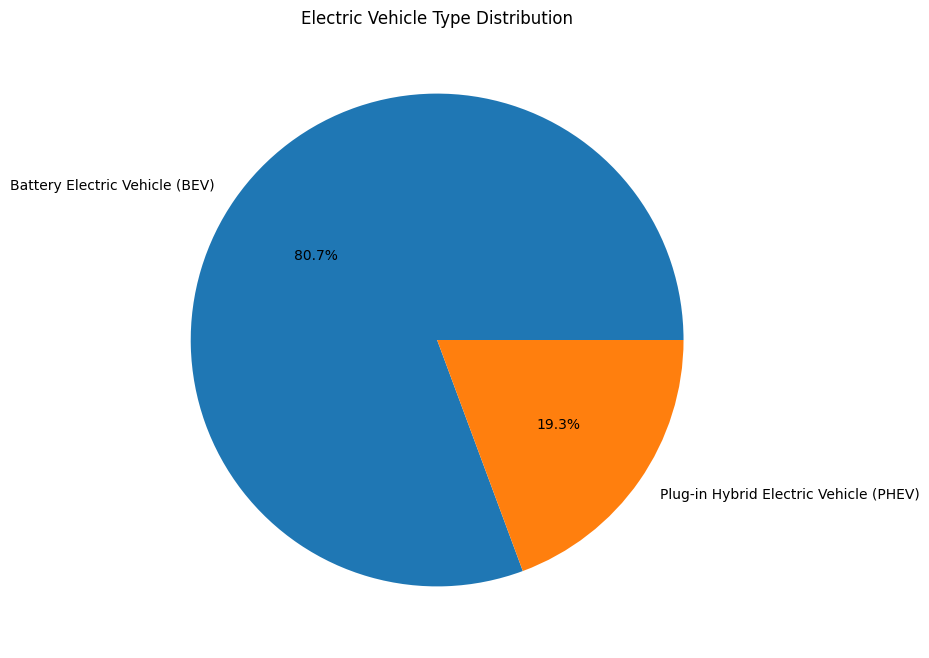

In [53]:
df["Electric Vehicle Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.title("Electric Vehicle Type Distribution")

plt.ylabel("")

plt.show()

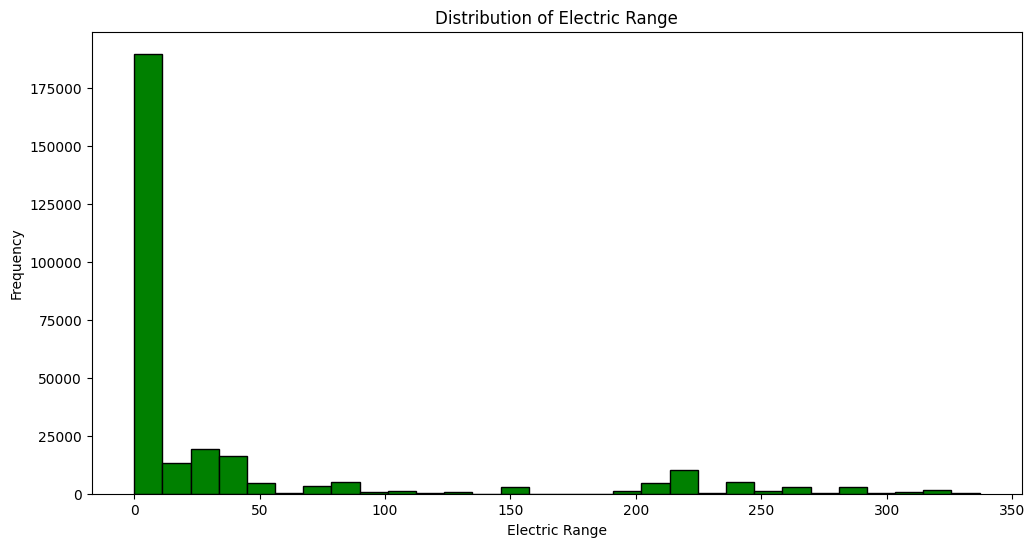

In [54]:
plt.figure(figsize=(12,6))

plt.hist(
    df["Electric Range"],
    bins=30,
    color="green",
    edgecolor="black"
)

plt.title("Distribution of Electric Range")
plt.xlabel("Electric Range")
plt.ylabel("Frequency")

plt.show()

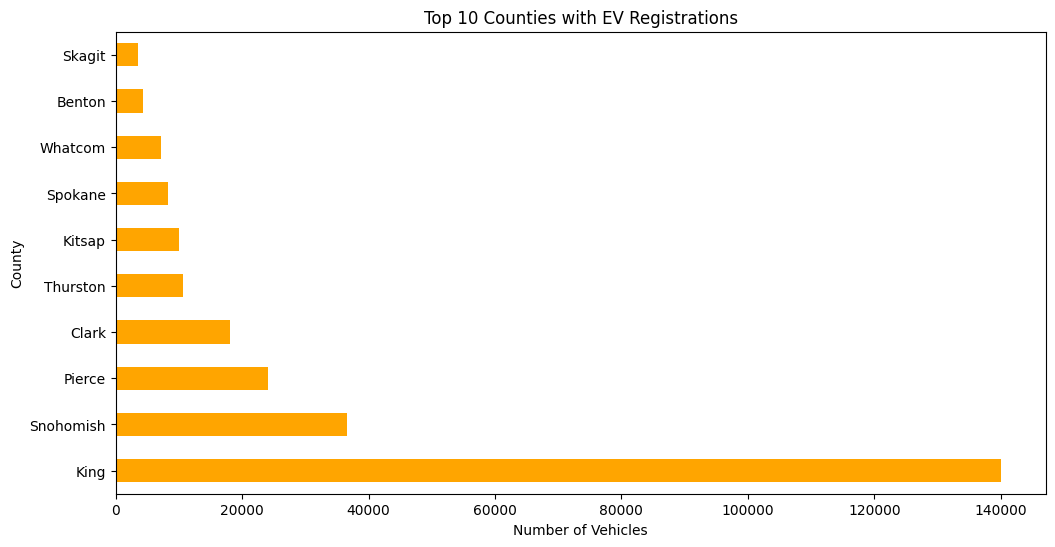

In [55]:
plt.figure(figsize=(12,6))

df["County"].value_counts().head(10).plot(
    kind="barh",
    color="orange"
)

plt.title("Top 10 Counties with EV Registrations")
plt.xlabel("Number of Vehicles")
plt.ylabel("County")

plt.show()

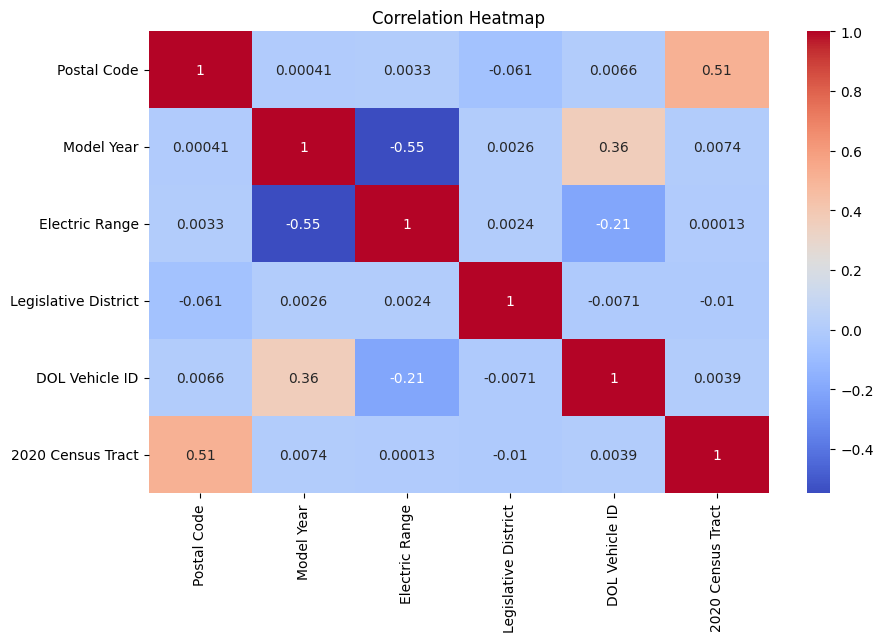

In [56]:
numeric_columns = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_columns.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

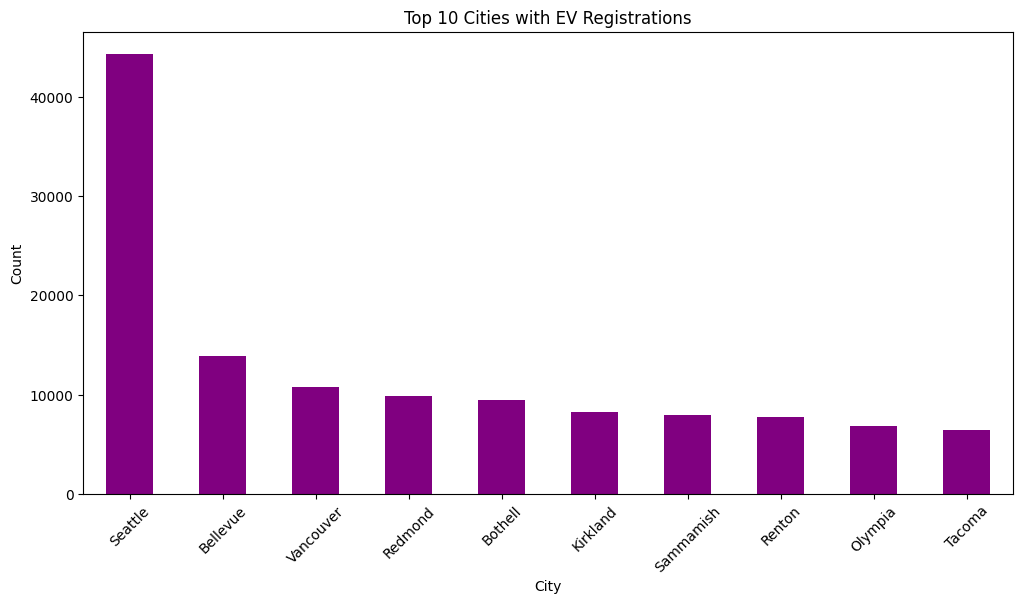

In [57]:
plt.figure(figsize=(12,6))

df["City"].value_counts().head(10).plot(
    kind="bar",
    color="purple"
)

plt.title("Top 10 Cities with EV Registrations")
plt.xlabel("City")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [59]:
ev_map = folium.Map(
    location=[47.4, -120.7],
    zoom_start=7
)

ev_map

# Section 4: Predictive Modeling (Linear Regression)

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [62]:
X = df[["Model Year"]]

y = df["Electric Range"]

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (231651, 1)
Testing Data: (57913, 1)


In [64]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [65]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[109.31447479  40.9087839   54.58992208 -13.81576881  -0.13463063
  40.9087839   54.58992208 122.99561297  40.9087839   40.9087839 ]


In [66]:
mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 4101.219789796567
R² Score: 0.30267074150883433


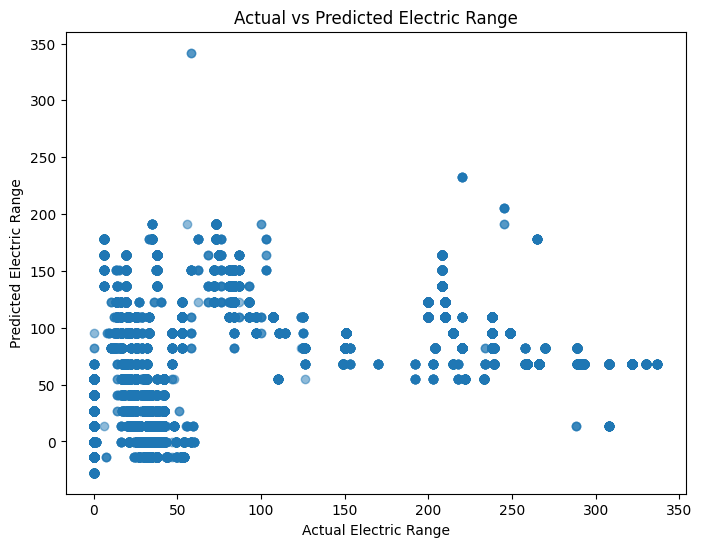

In [67]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Electric Range")
plt.ylabel("Predicted Electric Range")

plt.title("Actual vs Predicted Electric Range")

plt.show()

In [68]:
print("Intercept:", model.intercept_)

print("Coefficient:", model.coef_[0])

Intercept: 27704.170179309127
Coefficient: -13.681138177749823


# Section 5: Conclusion

In [69]:
print("EV Data Analysis Project Completed Successfully!")

EV Data Analysis Project Completed Successfully!


In [70]:
print("EV Data Analysis Project Completed Successfully!")

EV Data Analysis Project Completed Successfully!


## Conclusion

This project analyzed the Electric Vehicle (EV) dataset to understand adoption trends, vehicle types, manufacturers, geographic distribution, and electric range.

Key activities completed include:

- Imported and explored the EV dataset.
- Cleaned missing values and removed duplicate records.
- Performed Exploratory Data Analysis (EDA).
- Created multiple visualizations including bar charts, line charts, pie charts, histograms, heatmaps, and a geospatial map.
- Built a Linear Regression model to predict Electric Range using Model Year.
- Evaluated the model using Mean Squared Error (MSE) and R² Score.

This analysis provides valuable insights into electric vehicle adoption and demonstrates the application of Python for data analysis, visualization, and machine learning.

In [71]:
df.to_csv("EV_Cleaned_Data.csv", index=False)

print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!
